In [4]:
### Лаборатоная работа 4
# задание 1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

iris = load_iris()
print(iris.keys())
print(iris.target_names)

df =pd.DataFrame(
    iris.data,
    columns= iris.feature_names 
    )
df['target'] = iris.target

df['target'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

df = df.rename(columns={'sepal length (cm)': 'длина чашелистика (см)', 'sepal width (cm)': 'ширина чашелистика (см)',
                         'petal length (cm)': 'длина лепестков (см)', 'petal width (cm)': 'ширина лепестков (см)', 'target': 'вид'})
display(df.head())
display(df.tail())




dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
['setosa' 'versicolor' 'virginica']


,длина чашелистика (см),ширина чашелистика (см),длина лепестков (см),ширина лепестков (см),вид
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


,длина чашелистика (см),ширина чашелистика (см),длина лепестков (см),ширина лепестков (см),вид
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


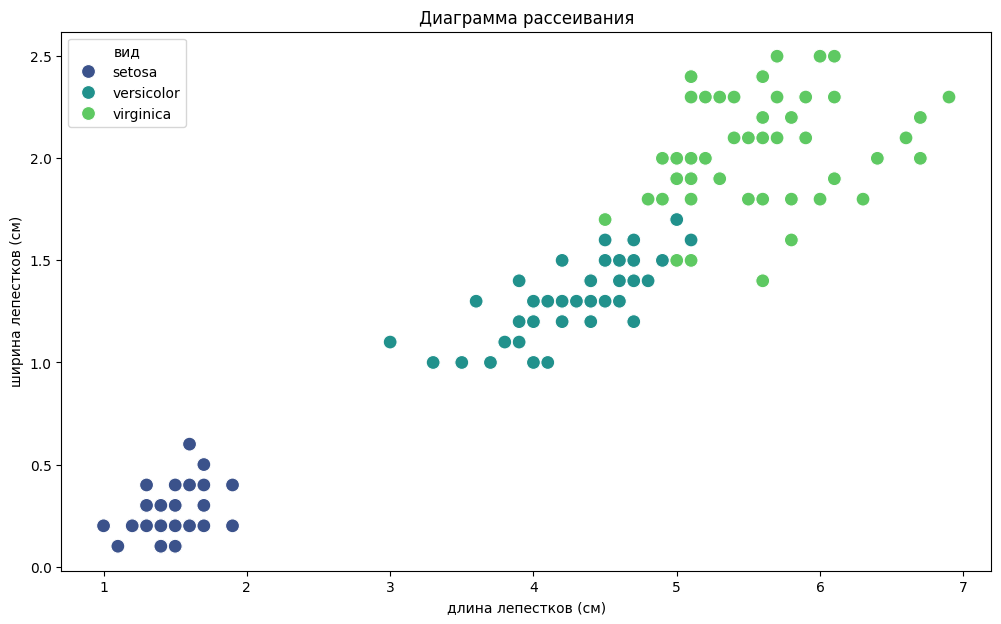

In [5]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data= df,
    x= 'длина лепестков (см)',
    y= 'ширина лепестков (см)',
    hue = 'вид',
    palette= 'viridis',
    s = 100
)

plt.title('Диаграмма рассеивания')
plt.show()


In [6]:
# задание2

import statsmodels.api as sm

df = sm.datasets.grunfeld.load_pandas().data
print(df)
display(df.describe(include= 'object'))
print(df['firm'].unique())

# отбираем 3 любые фирмы
firms = ['General Motors', 'US Steel', 'General Electric']

df_1 = df[df['firm'].isin(firms)]
display(df_1.describe(include= 'object'))

      invest     value  capital            firm    year
0    317.600  3078.500    2.800  General Motors  1935.0
1    391.800  4661.700   52.600  General Motors  1936.0
2    410.600  5387.100  156.900  General Motors  1937.0
3    257.700  2792.200  209.200  General Motors  1938.0
4    330.800  4313.200  203.400  General Motors  1939.0
..       ...       ...      ...             ...     ...
215    4.770    36.494   75.847  American Steel  1950.0
216    6.532    46.082   77.367  American Steel  1951.0
217    7.329    57.616   78.631  American Steel  1952.0
218    9.020    57.441   80.215  American Steel  1953.0
219    6.281    47.165   83.788  American Steel  1954.0

[220 rows x 5 columns]


,firm
count,220
unique,11
top,General Motors
freq,20


['General Motors' 'US Steel' 'General Electric' 'Chrysler'
 'Atlantic Refining' 'IBM' 'Union Oil' 'Westinghouse' 'Goodyear'
 'Diamond Match' 'American Steel']


,firm
count,60
unique,3
top,General Motors
freq,20


In [8]:
df_1 = df_1.rename(columns= {'invest': 'инвестиции', 'value': 'стоимость', 'capital': 'капитал', 'firm': 'фирма', 'year': 'год'})
display(df_1.head(5))

,инвестиции,стоимость,капитал,фирма,год
0,317.6,3078.5,2.8,General Motors,1935.0
1,391.8,4661.7,52.6,General Motors,1936.0
2,410.6,5387.1,156.9,General Motors,1937.0
3,257.7,2792.2,209.2,General Motors,1938.0
4,330.8,4313.2,203.4,General Motors,1939.0


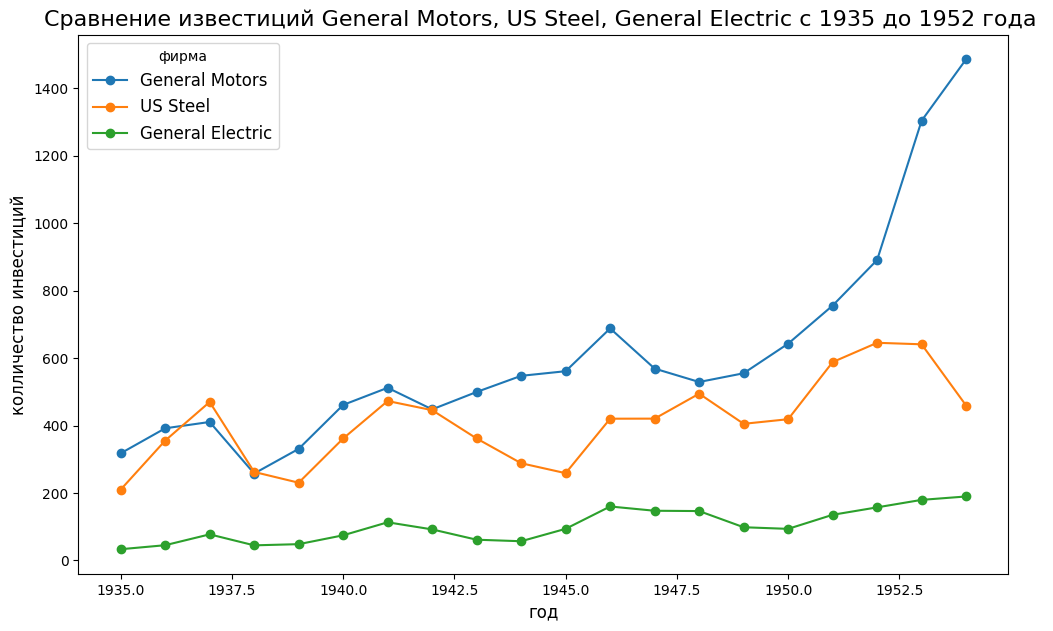

In [10]:
plt.figure(figsize= (12, 7))

for i in firms:
    df_firm = df_1[df_1['фирма'] == i]
    plt.plot(
        df_firm['год'],
        df_firm['инвестиции'],
        marker = 'o',
        label = i
    )


plt.title('Сравнение известиций General Motors, US Steel, General Electric с 1935 до 1952 года ', fontsize = 16)
plt.xlabel('год', fontsize = 12),
plt.ylabel('колличество инвестиций', fontsize = 12)

plt.legend(
    title = 'фирма',
    loc = 'upper left',
    fontsize = 12
)

plt.show()
